# Interpret cell populations with scATAC-seq

Single-cell ATAC-seq measures chromatin accessibility: regions where DNA is accessible
to the assay. Its features are **peaks**, genomic intervals with accessibility signal.
A peak may overlap a gene, promoter, or other regulatory region; its coordinates tell us
where to look in the reference genome.

Here we use a prepared PBMC analysis to find populations with similar accessibility.
We then combine peaks overlapping gene regions into **GeneScores** and ask which broad
cell identities their marker patterns support.

## Open the prepared ATAC result

In [1]:
# Open count stores and run CyteArc analyses.
import cytearc

# Keep routine logs and progress bars out of the results.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_10K_pbmc-v1_atacseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the count store for this analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", default_assay="ATAC", nthreads=4)

# Inspect the opened store's cells and features.
ds

DataStore has 8426 (8728) cells with 1 assays: ATAC
   Cell metadata:
            'I', 'ids', 'names', 'ATAC_UMAP1', 'ATAC_UMAP2', 
            'ATAC_leiden_cluster', 'ATAC_nCounts', 'ATAC_nFeatures'
   ATAC assay has 89796 features and following metadata:
            'I', 'ids', 'names', 'derivation', 'dropOuts', 
            'feature_type', 'genome', 'nCells'

Started: 2026-10-08T13:05:01.784380Z | Wall time: 27.416 s

Preprocessing is complete in this store. Retrieve its UMAP and Leiden clusters:

In [2]:
# Select the saved ATAC clusters; require exactly one match.
clusters = ds.artifacts.find("clusters", from_assay="ATAC", method="leiden")

# Select the saved ATAC UMAP; require exactly one match.
umap = ds.artifacts.find("embedding", from_assay="ATAC", method="umap")

# Inspect the saved ATAC clustering and layout.
{"clusters": clusters, "UMAP": umap}

{'clusters': ArtifactRef(assay='ATAC', kind='cluster_labels', artifact_id='aa627598be0d...'),
 'UMAP': ArtifactRef(assay='ATAC', kind='embedding', artifact_id='2307d298e8cf...')}

Started: 2026-10-08T13:05:29.211521Z | Wall time: 0.030 s

## Find accessibility populations

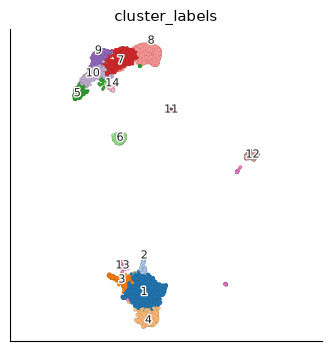

Started: 2026-10-08T13:05:29.246141Z | Wall time: 2.045 s

In [3]:
# Locate the ATAC clusters before interpreting their markers.
ds.plots.embedding(layout=umap, color_by=clusters, legend_loc='on_data')

Each point is a cell. Nearby cells tend to share accessible peaks. The numbered clusters
give us groups to investigate, but we need marker evidence to attach biological names.

## Connect peaks to genes

A BED file describes genomic intervals and their gene names. Use an annotation built for
the same reference genome as the peaks; this dataset uses GRCh37. CyteArc combines the
accessibility signal from overlapping peaks into a new assay named `GeneScores`.

Here `renormalization=False` keeps the combined scores without an extra rescaling during
assay construction. `assay_type="RNA"` gives the new assay RNA-style normalization for
plotting. This does not turn accessibility into measured RNA expression.

In [4]:
# Download gene intervals for the dataset's reference genome.
annotations = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "annotations",
    destination="cytearc_datasets",
)

# Combine peaks overlapping gene intervals into GeneScores.
ds.add_melded_assay(
    from_assay="ATAC",
    external_bed_fn=f"{annotations}/human_GRCh37_gencode_v38_gene_body.bed.gz",
    renormalization=False,
    assay_label="GeneScores",
    assay_type="RNA",
)

# Inspect the opened store's cells and features.
ds

DataStore has 8426 (8728) cells with 2 assays: ATAC GeneScores
   Cell metadata:
            'I', 'ids', 'names', 'ATAC_UMAP1', 'ATAC_UMAP2', 
            'ATAC_leiden_cluster', 'ATAC_nCounts', 'ATAC_nFeatures', 'GeneScores_nCounts', 'GeneScores_nFeatures', 
            'GeneScores_percentMito', 'GeneScores_percentRibo'
   ATAC assay has 89796 features and following metadata:
            'I', 'ids', 'names', 'derivation', 'dropOuts', 
            'feature_type', 'genome', 'nCells'
   GeneScores assay has 62446 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells'

Started: 2026-10-08T13:05:31.296206Z | Wall time: 52.732 s

Annotation genes with no overlapping peaks remain as zero-count features and are marked
invalid. They are not evidence that a gene is inaccessible in every biological setting.

## Read the marker maps

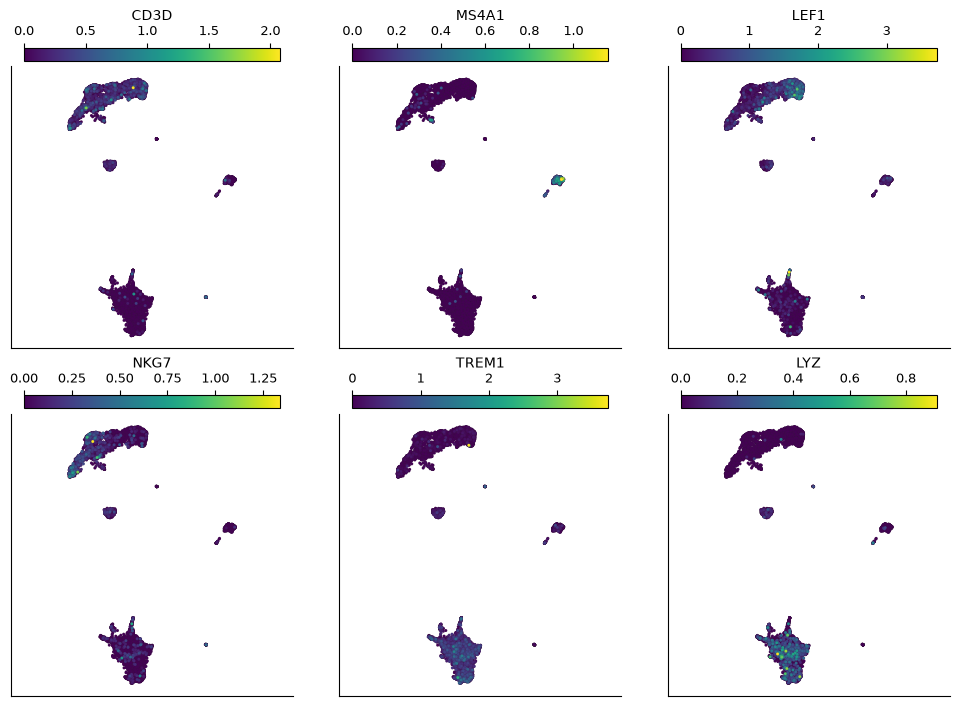

Started: 2026-10-08T13:06:24.033422Z | Wall time: 5.065 s

In [5]:
# Compare GeneScores for lymphoid and myeloid markers.
ds.plots.embedding(
    layout=umap,
    from_assay="GeneScores",
    color_by=["CD3D", "MS4A1", "LEF1", "NKG7", "TREM1", "LYZ"],
    n_columns=3,
    sort_values=True,
)

CD3D and LEF1 support T-cell regions, MS4A1 supports B cells, and NKG7 highlights
cytotoxic or NK-like populations. TREM1 together with LYZ supports myeloid populations.
Look for agreement across markers rather than assigning a type from one bright panel.
See [](annotation.ipynb) for broader panels and checks against alternative identities.

## Start from your own peak counts

Convert and open a peak-count matrix with `default_assay="ATAC"` as shown in
[](import_and_export.ipynb). After reviewing its quality measurements in
[](quality_control.ipynb), this sequence uses the default settings to build a first result:

```python
# Open your own ATAC count store.
own_ds = cytearc.DataStore("my_atac.zarr", default_assay="ATAC")

# Filter cells using the available quality measurements.
cells = own_ds.qc.auto_filter()

# Select peaks detected across the retained cells.
peaks = own_ds.features.prevalent_peaks(cells)

# Normalize counts over the selected features.
normalized = own_ds.features.normalize(cells, peaks)

# Reduce TF-IDF normalized accessibility with LSI.
lsi = own_ds.reduction.lsi(normalized)

# Build starting coordinates for the embedding.
initialization = own_ds.embeddings.initialization(lsi)

# Build the nearest-neighbor search index from LSI.
neighbor_index = own_ds.graph.ann_index(lsi)

# Find neighbors of each cell in the reduced space.
neighbors = own_ds.graph.neighbors(neighbor_index)

# Convert neighbor distances into weighted connectivity.
graph = own_ds.graph.connectivity(neighbors)

# Keep the saved UMAP coordinates for the figures.
layout = own_ds.embeddings.umap(graph, initialization)

# Find groups of cells in the graph.
clusters = own_ds.clusters.leiden(graph)
```

For ATAC, normalization uses TF-IDF and dimensionality reduction uses LSI. Treat defaults
as a starting point: inspect the retained cells and marker patterns before adjusting
peak selection, LSI dimensions, or neighborhood size. The next steps are explained in
[](feature_selection.ipynb), [](dimensionality_reduction.ipynb), and [](graph_construction.ipynb).

## Common mistakes and limitations

- Reading accessibility as expression: an accessible region does not guarantee transcription or protein production, and GeneScores combine peak signal into an RNA-style assay without measuring RNA.
- Trusting the annotation's reach: scores depend on the intervals you supply, so gene-body scores miss distant regulatory elements, and genes with no overlapping peaks remain invalid zero features rather than evidence of inaccessibility.
- Resolving fine identities with a broad panel: the marker patterns shown here support lineage-level calls; finer states need additional markers and independent evidence.